# Python. Исследовательский анализ данных

- Автор: Аникин Никита
- Дата: 06.06.2026

### Цели и задачи проекта

<font color='#777778'>Провести исследовательский анализ данных заведений общественного питания Москвы, выявить особенности их распределения по категориям, районам, ценовым сегментам и сетевой принадлежности, а также определить факторы, связанные с рейтингами и уровнем цен.</font>

### Описание данных

<font color='#777778'>Данные содержат 14 столбцов, есть как и числовые значения так и категориальные</font>

### Содержимое проекта
1)Загрузка и первичное изучение данных.
2)Предобработка данных
3)Исследовательский анализ данных
4) Выводы и рекомендации

---

## 1. Загрузка данных и знакомство с ними

- Загрузите данные о заведениях общественного питания Москвы. Путь к файлам: `/datasets/rest_info.csv` и `/datasets/rest_price.csv`.

In [50]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [51]:
rest_info = pd.read_csv('https://code.s3.yandex.net/datasets/rest_info.csv')
rest_price = pd.read_csv('https://code.s3.yandex.net/datasets/rest_price.csv')


In [52]:
rest_info.head()

,id,name,category,address,district,hours,rating,chain,seats
0,0c3e3439a8c64ea5bf6ecd6ca6ae19f0,WoWфли,кафе,"Москва, улица Дыбенко, 7/1",Северный административный округ,"ежедневно, 10:00–22:00",5.0,0,NaN
1,045780ada3474c57a2112e505d74b633,Четыре комнаты,ресторан,"Москва, улица Дыбенко, 36, корп. 1",Северный административный округ,"ежедневно, 10:00–22:00",4.5,0,4.0
2,1070b6b59144425896c65889347fcff6,Хазри,кафе,"Москва, Клязьминская улица, 15",Северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",4.6,0,45.0
3,03ac7cd772104f65b58b349dc59f03ee,Dormouse Coffee Shop,кофейня,"Москва, улица Маршала Федоренко, 12",Северный административный округ,"ежедневно, 09:00–22:00",5.0,0,NaN
4,a163aada139c4c7f87b0b1c0b466a50f,Иль Марко,пиццерия,"Москва, Правобережная улица, 1Б",Северный административный округ,"ежедневно, 10:00–22:00",5.0,1,148.0


In [53]:
rest_info.info() #Видим пропуски в часах и в кол-ве посадочных мест, что в целом не удивительно ведь,
#такая информация может указываться не везде

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8406 entries, 0 to 8405
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        8406 non-null   object 
 1   name      8406 non-null   object 
 2   category  8406 non-null   object 
 3   address   8406 non-null   object 
 4   district  8406 non-null   object 
 5   hours     7870 non-null   object 
 6   rating    8406 non-null   float64
 7   chain     8406 non-null   int64  
 8   seats     4795 non-null   float64
dtypes: float64(2), int64(1), object(6)
memory usage: 591.2+ KB


- Познакомьтесь с данными и изучите общую информацию о них.

In [54]:
rest_price.head()

,id,price,avg_bill,middle_avg_bill,middle_coffee_cup
0,045780ada3474c57a2112e505d74b633,выше среднего,Средний счёт:1500–1600 ₽,1550.0,NaN
1,1070b6b59144425896c65889347fcff6,средние,Средний счёт:от 1000 ₽,1000.0,NaN
2,03ac7cd772104f65b58b349dc59f03ee,NaN,Цена чашки капучино:155–185 ₽,NaN,170.0
3,a163aada139c4c7f87b0b1c0b466a50f,средние,Средний счёт:400–600 ₽,500.0,NaN
4,8a343546b24e4a499ad96eb7d0797a8a,средние,NaN,NaN,NaN


In [55]:
rest_price.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4058 entries, 0 to 4057
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 4058 non-null   object 
 1   price              3315 non-null   object 
 2   avg_bill           3816 non-null   object 
 3   middle_avg_bill    3149 non-null   float64
 4   middle_coffee_cup  535 non-null    float64
dtypes: float64(2), object(3)
memory usage: 158.6+ KB


---

### Промежуточный вывод

Сделайте промежуточный вывод о полученных данных: данные какого объёма вам предоставили, соответствуют ли данные описанию, встречаются ли в них пропуски, используются ли верные типы данных. Отметьте другие особенности данных, которые вы обнаружите на этой стадии и на которые стоит обратить внимание при предобработке.

Первое на что я обратил внимания так это на типы данных, в основном они указаны верно, но chain можно оптимизировать
Если он хранит только булевые значение, возможно стоит лучше перевести его в другой тип данных. В таблице rest_price пропуски встречаются в столбцах price, avg_bill, middle_avg_bill и особенно в middle_coffee_cup, где заполнена лишь небольшая часть значений. 

Нужно будет проверить на наличие дубликатов, стоит отметить что записей в rest_price, почти вдвое меньше,
это связано с тем что вероятнее всего только в половине заведений указаны данные по ценам и среднему чеку.


### Подготовка единого датафрейма

- Объедините данные двух датасетов в один, с которым вы и продолжите работу.

In [56]:
df = rest_info.merge(rest_price, on='id', how='left')

In [57]:
df.head()

,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup
0,0c3e3439a8c64ea5bf6ecd6ca6ae19f0,WoWфли,кафе,"Москва, улица Дыбенко, 7/1",Северный административный округ,"ежедневно, 10:00–22:00",5.0,0,NaN,NaN,NaN,NaN,NaN
1,045780ada3474c57a2112e505d74b633,Четыре комнаты,ресторан,"Москва, улица Дыбенко, 36, корп. 1",Северный административный округ,"ежедневно, 10:00–22:00",4.5,0,4.0,выше среднего,Средний счёт:1500–1600 ₽,1550.0,NaN
2,1070b6b59144425896c65889347fcff6,Хазри,кафе,"Москва, Клязьминская улица, 15",Северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",4.6,0,45.0,средние,Средний счёт:от 1000 ₽,1000.0,NaN
3,03ac7cd772104f65b58b349dc59f03ee,Dormouse Coffee Shop,кофейня,"Москва, улица Маршала Федоренко, 12",Северный административный округ,"ежедневно, 09:00–22:00",5.0,0,NaN,NaN,Цена чашки капучино:155–185 ₽,NaN,170.0
4,a163aada139c4c7f87b0b1c0b466a50f,Иль Марко,пиццерия,"Москва, Правобережная улица, 1Б",Северный административный округ,"ежедневно, 10:00–22:00",5.0,1,148.0,средние,Средний счёт:400–600 ₽,500.0,NaN


In [58]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8406 entries, 0 to 8405
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 8406 non-null   object 
 1   name               8406 non-null   object 
 2   category           8406 non-null   object 
 3   address            8406 non-null   object 
 4   district           8406 non-null   object 
 5   hours              7870 non-null   object 
 6   rating             8406 non-null   float64
 7   chain              8406 non-null   int64  
 8   seats              4795 non-null   float64
 9   price              3315 non-null   object 
 10  avg_bill           3816 non-null   object 
 11  middle_avg_bill    3149 non-null   float64
 12  middle_coffee_cup  535 non-null    float64
dtypes: float64(4), int64(1), object(8)
memory usage: 853.9+ KB


## 2. Предобработка данных

Подготовьте данные к исследовательскому анализу:

- Изучите корректность типов данных и при необходимости проведите их преобразование.

Из данных думаю что единственное что стоит изменить так это поменять тип данных chain с int на булевые значения.

In [59]:
df['chain'] = df['chain'].astype(bool)

In [60]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8406 entries, 0 to 8405
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 8406 non-null   object 
 1   name               8406 non-null   object 
 2   category           8406 non-null   object 
 3   address            8406 non-null   object 
 4   district           8406 non-null   object 
 5   hours              7870 non-null   object 
 6   rating             8406 non-null   float64
 7   chain              8406 non-null   bool   
 8   seats              4795 non-null   float64
 9   price              3315 non-null   object 
 10  avg_bill           3816 non-null   object 
 11  middle_avg_bill    3149 non-null   float64
 12  middle_coffee_cup  535 non-null    float64
dtypes: bool(1), float64(4), object(8)
memory usage: 796.4+ KB


- Изучите пропущенные значения в данных: посчитайте их количество в каждом столбце датафрейме, изучите данные с пропущенными значениями и предположите гипотезы их появления. Проведите обработку пропущенных значений: вы можете заменить пропуски на определённое значение, удалить строки с пропусками или оставить их как есть.

In [61]:
df.isna().sum()

id                      0
name                    0
category                0
address                 0
district                0
hours                 536
rating                  0
chain                   0
seats                3611
price                5091
avg_bill             4590
middle_avg_bill      5257
middle_coffee_cup    7871
dtype: int64

In [62]:
(df.isna().mean() * 100).sort_values(ascending=False)

middle_coffee_cup    93.635498
middle_avg_bill      62.538663
price                60.563883
avg_bill             54.603854
seats                42.957411
hours                 6.376398
id                    0.000000
name                  0.000000
category              0.000000
address               0.000000
district              0.000000
rating                0.000000
chain                 0.000000
dtype: float64

Очень большое количество пропусков есть в категориях middle_coffee_cup,middle_avg_bill, price, но все эти пропуски связаны не с какой-то ошибкой, а с нехваткой информации, удалять такие пропуски думаю не стоит потому что их доля весьма большая, достигает больше половины значений, поэтому лучше оставить так как есть.

- Проверьте данные на явные и неявные дубликаты, например поля с названием и адресом заведения. Для оптимизации проверки нормализуйте данные в текстовых столбцах, например с названием заведения.

In [63]:
df.duplicated().sum() #явных дубликатов нет

np.int64(0)

In [64]:
df['name'] = df['name'].str.lower().str.strip()

In [65]:
df.duplicated(subset=['name', 'address']).sum() #По одному лишь названию выявлять некорректно, т.к у одной сети может быть несколько филлиалов

np.int64(3)

In [66]:
df = df.drop_duplicates(subset=['name','address'])
df.duplicated(subset=['name', 'address']).sum()

np.int64(0)

- Для дальнейшей работы создайте столбец `is_24_7` с обозначением того, что заведение работает ежедневно и круглосуточно, то есть 24/7:
  - логическое значение `True` — если заведение работает ежедневно и круглосуточно;
  - логическое значение `False` — в противоположном случае.

In [67]:
df['is_24_7'] = df['hours'].str.lower() == 'ежедневно, круглосуточно'

In [68]:
df.head()


,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup,is_24_7
0,0c3e3439a8c64ea5bf6ecd6ca6ae19f0,wowфли,кафе,"Москва, улица Дыбенко, 7/1",Северный административный округ,"ежедневно, 10:00–22:00",5.0,False,NaN,NaN,NaN,NaN,NaN,False
1,045780ada3474c57a2112e505d74b633,четыре комнаты,ресторан,"Москва, улица Дыбенко, 36, корп. 1",Северный административный округ,"ежедневно, 10:00–22:00",4.5,False,4.0,выше среднего,Средний счёт:1500–1600 ₽,1550.0,NaN,False
2,1070b6b59144425896c65889347fcff6,хазри,кафе,"Москва, Клязьминская улица, 15",Северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",4.6,False,45.0,средние,Средний счёт:от 1000 ₽,1000.0,NaN,False
3,03ac7cd772104f65b58b349dc59f03ee,dormouse coffee shop,кофейня,"Москва, улица Маршала Федоренко, 12",Северный административный округ,"ежедневно, 09:00–22:00",5.0,False,NaN,NaN,Цена чашки капучино:155–185 ₽,NaN,170.0,False
4,a163aada139c4c7f87b0b1c0b466a50f,иль марко,пиццерия,"Москва, Правобережная улица, 1Б",Северный административный округ,"ежедневно, 10:00–22:00",5.0,True,148.0,средние,Средний счёт:400–600 ₽,500.0,NaN,False


---

### Промежуточный вывод

После предобработки данных напишите промежуточный вывод о проведённой работе. Отразите количество или долю отфильтрованных данных, если вы что-то удаляли.

Была проделана работа с дубликатами. Явных дубликатов мы не обнаружили, однака дубликаты всё же были, несколько заведений дублировались, такие дубликаты мы удалили и продолжили работу. Был создан столбец is_24_7, теперь мы можем узнать работает ли заведение 24 часа каждый день или нет.

In [69]:
df['is_24_7'].sum() 

np.int64(730)

In [70]:
df['is_24_7'].value_counts(normalize=True) * 100

is_24_7
False    91.312626
True      8.687374
Name: proportion, dtype: float64

Как мы можем увидеть 91 процент всех заведений не работает 24/7

## 3. Исследовательский анализ данных
Проведите исследовательский анализ исходных данных.

При исследовании данных используйте визуализации. Проверьте, что для каждого случая подобран оптимальный тип визуализации с корректным оформлением. У графика должен быть заголовок, понятные подписи по осям, при необходимости легенда, а его размер является оптимальным для изучения.

После исследования каждого пункта оставляйте небольшой комментарий с выводом или обсуждением результата. В конце шага обобщите результаты, выделив, по вашему мнению, самые важные.

---

### Задача 1

Какие категории заведений представлены в данных? Исследуйте количество объектов общественного питания по каждой категории. Результат сопроводите подходящей визуализацией.

In [71]:
df['category']

0           кафе
1       ресторан
2           кафе
3        кофейня
4       пиццерия
          ...   
8401        кафе
8402        кафе
8403        кафе
8404        кафе
8405        кафе
Name: category, Length: 8403, dtype: object

In [72]:
category_counts = df['category'].value_counts()

In [73]:
category_counts

category
кафе               2377
ресторан           2042
кофейня            1413
бар,паб             764
пиццерия            633
быстрое питание     603
столовая            315
булочная            256
Name: count, dtype: int64

Text(0, 0.5, 'Количество')

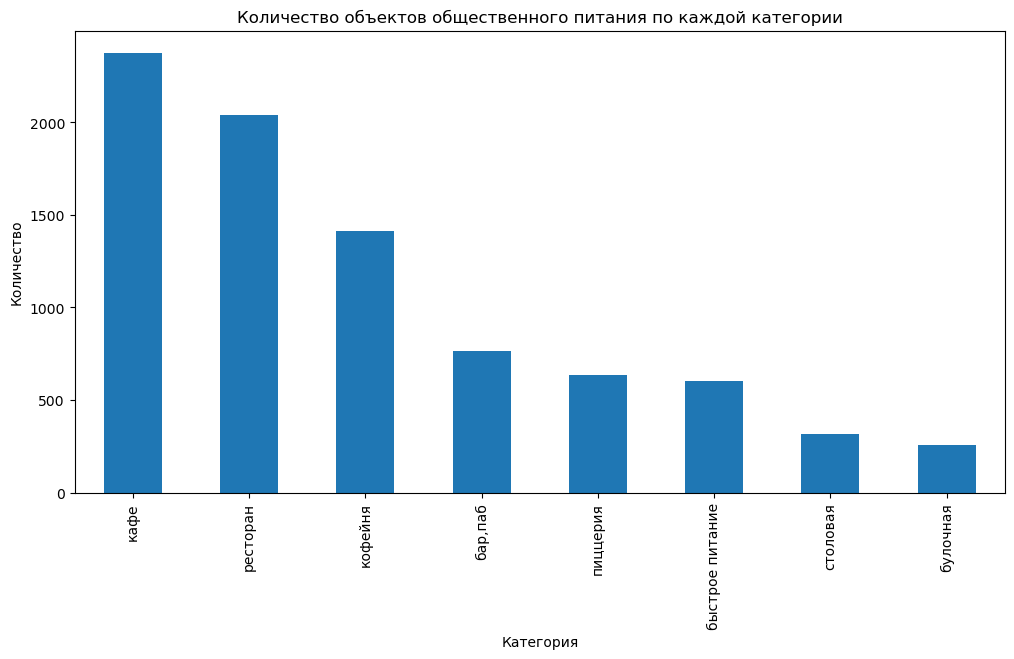

In [74]:
plt.figure(figsize=(12, 6))
category_counts.plot(kind='bar')
plt.title('Количество объектов общественного питания по каждой категории')
plt.xlabel('Категория')
plt.ylabel('Количество')

По графику видно что самая популярная категория это кафе и рестораны. 

---

### Задача 2

Какие административные районы Москвы присутствуют в данных? Исследуйте распределение количества заведений по административным районам Москвы, а также отдельно распределение заведений каждой категории в Центральном административном округе Москвы. Результат сопроводите подходящими визуализациями.

In [75]:
df['district'].unique()

array(['Северный административный округ',
       'Северо-Восточный административный округ',
       'Северо-Западный административный округ',
       'Западный административный округ',
       'Центральный административный округ',
       'Восточный административный округ',
       'Юго-Восточный административный округ',
       'Южный административный округ',
       'Юго-Западный административный округ'], dtype=object)

Всего присутствуют 9 округов

In [76]:
district_counts = df['district'].value_counts()

Text(0, 0.5, 'Округ')

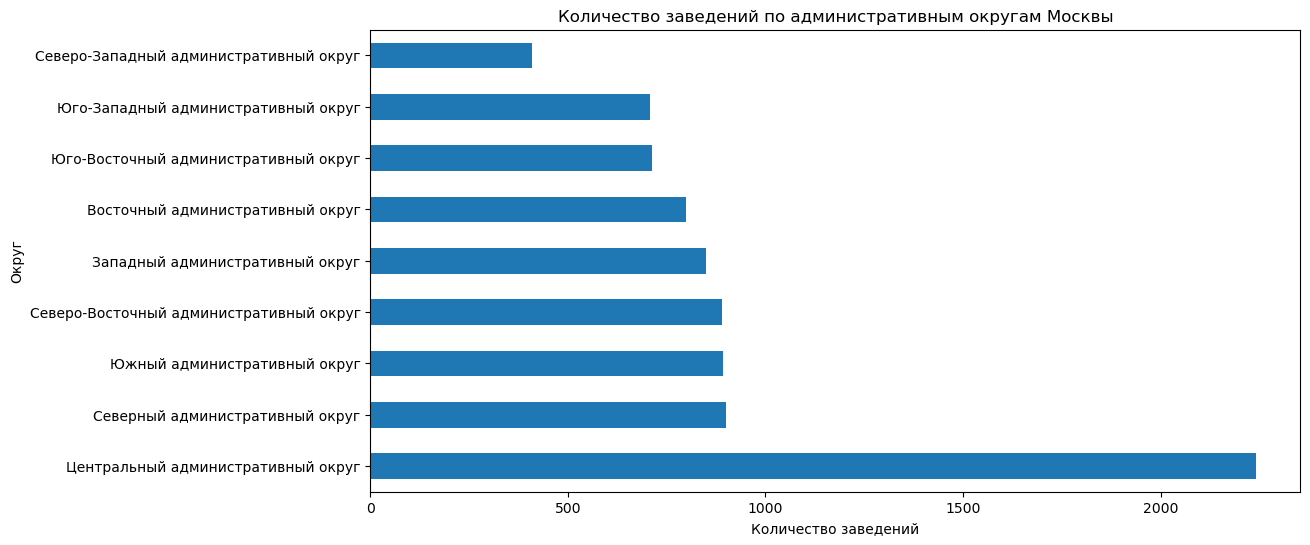

In [77]:
plt.figure(figsize=(12, 6))
district_counts.plot(kind='barh')
plt.title('Количество заведений по административным округам Москвы')
plt.xlabel('Количество заведений')
plt.ylabel('Округ')

Видно как ЦАО лидирует с большим отрывом, большая сеть заведений открыта именно там.

In [78]:
cao = df[df['district'] == 'Центральный административный округ']

In [79]:
category_counts = cao['category'].value_counts()

Text(0, 0.5, 'Тип заведения')

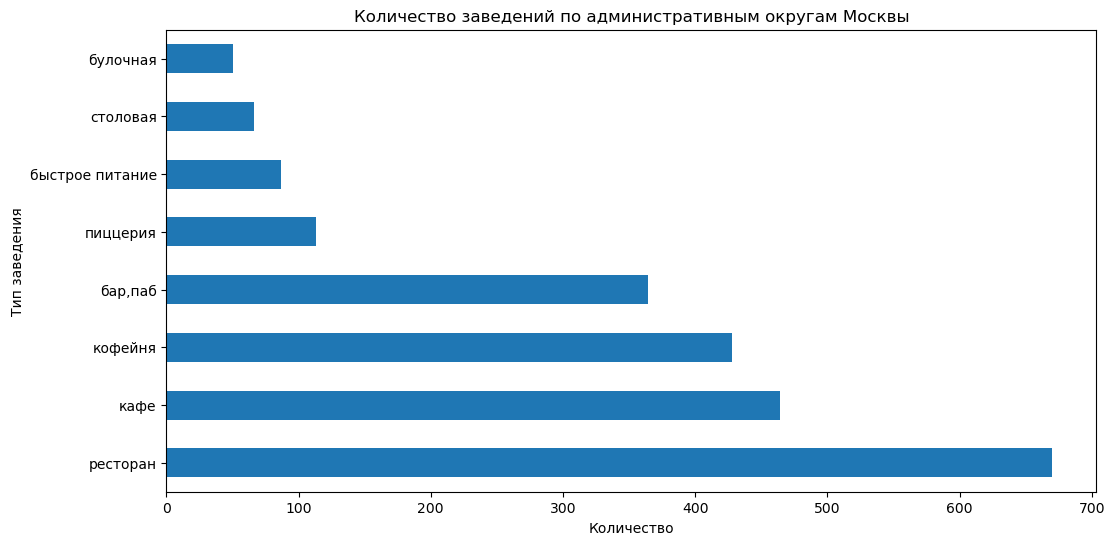

In [80]:
plt.figure(figsize=(12, 6))
category_counts.plot(kind='barh')
plt.title('Количество заведений по административным округам Москвы')
plt.xlabel('Количество')
plt.ylabel('Тип заведения')

Больше всего в этом округе находятся рестораны

---

### Задача 3

Изучите соотношение сетевых и несетевых заведений в целом по всем данным и в разрезе категорий заведения. Каких заведений больше — сетевых или несетевых? Какие категории заведений чаще являются сетевыми? Исследуйте данные, ответьте на вопросы и постройте необходимые визуализации.

In [81]:
chain_counts = df['chain'].value_counts()

In [82]:
chain_counts #Видим что сетевых заведений меньше, их всего 3203 шт.

chain
False    5200
True     3203
Name: count, dtype: int64

Text(0, 0.5, 'Количество')

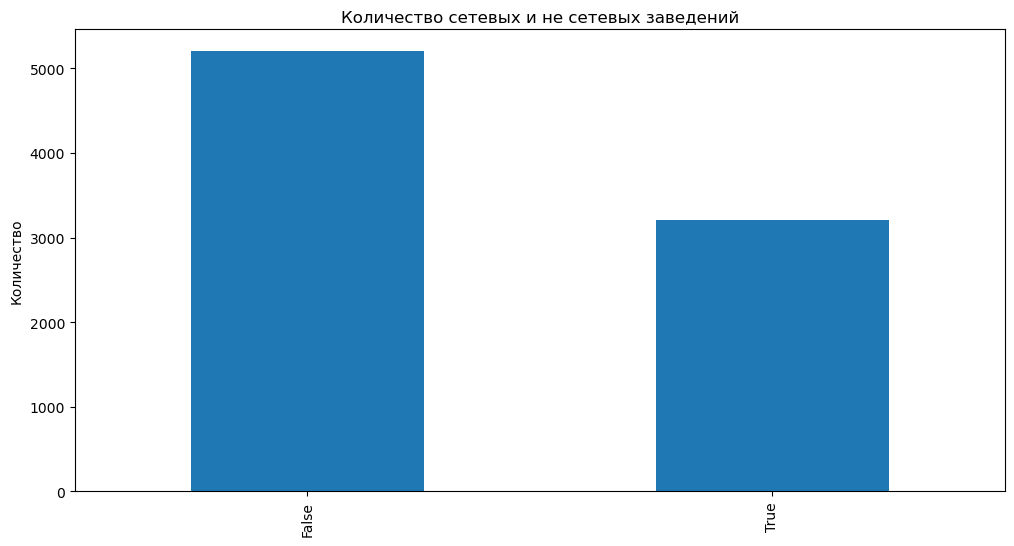

In [83]:
plt.figure(figsize=(12, 6))
chain_counts.plot(kind='bar')
plt.title('Количество сетевых и не сетевых заведений')
plt.xlabel('')
plt.ylabel('Количество')

Теперь выполним соотношение по категорям

In [84]:
category_chain = (
    df.groupby(['category', 'chain'])
      .size()
      .unstack(fill_value=0)
)

category_chain

chain,False,True
category,,
"бар,паб",596,168
булочная,99,157
быстрое питание,371,232
кафе,1598,779
кофейня,693,720
пиццерия,303,330
ресторан,1313,729
столовая,227,88


У меня есть вопрос, почему в теории этого спринта не дают прекрасный метод crosstab? О нём вроде бы вообще не было ни слова, я понимаю что groupby он более универсален, но тем не менее, как будто бы для этого спринта было бы легче использовать именно его

Что касается вывода, можно заметить что больше всего сетевых заведений у кафешек. сделом за ними идут рестораны и кофейни.

Text(0, 0.5, 'Количество')

<Figure size 1200x600 with 0 Axes>

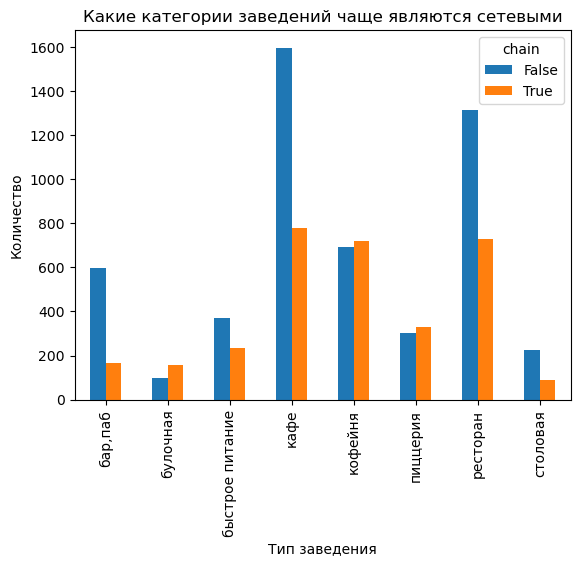

In [85]:
plt.figure(figsize=(12, 6))
category_chain.plot(kind='bar')
plt.title('Какие категории заведений чаще являются сетевыми')
plt.xlabel('Тип заведения')
plt.ylabel('Количество')

---

### Задача 4

Исследуйте количество посадочных мест в заведениях. Встречаются ли в данных аномальные значения или выбросы? Если да, то с чем они могут быть связаны? Приведите для каждой категории заведений наиболее типичное для него количество посадочных мест. Результат сопроводите подходящими визуализациями.


In [86]:
df['seats'].describe()

count    4792.000000
mean      108.361436
std       122.841130
min         0.000000
25%        40.000000
50%        75.000000
75%       140.000000
max      1288.000000
Name: seats, dtype: float64

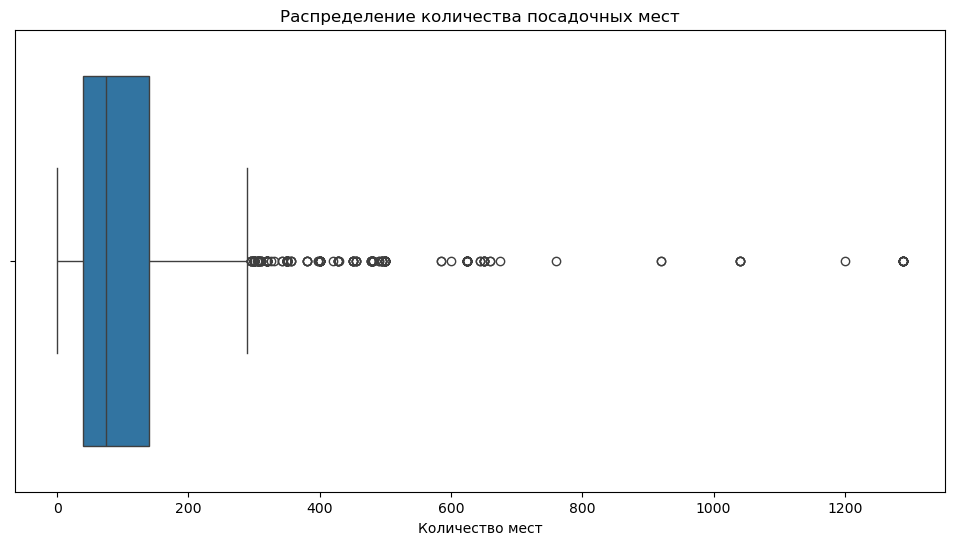

In [87]:
plt.figure(figsize=(12, 6))
sns.boxplot(x=df['seats'])

plt.title('Распределение количества посадочных мест')
plt.xlabel('Количество мест')
plt.show()

В целом есть выброс где указано 1288 мест, большинство заведений имеют от 40 до 140 посадочных мест, а медианное значение составляет около 80-100 мест.

In [88]:
df_filtered_seats = df[df['seats'] > 1200] #Хочу проверить почему такие выбросы

In [89]:
df_filtered_seats

,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup,is_24_7
6518,fbf22d98b62a47fbb2a71be3545f16b2,delonixcafe,ресторан,"Москва, проспект Вернадского, 94, корп. 1",Западный административный округ,"ежедневно, круглосуточно",4.1,False,1288.0,высокие,Средний счёт:1500–2000 ₽,1750.0,NaN,True
6524,c93d20f53072495c9cf2e489914cb8a5,ян примус,ресторан,"Москва, проспект Вернадского, 121, корп. 1",Западный административный округ,"пн-чт 12:00–00:00; пт,сб 12:00–02:00; вс 12:00...",4.5,True,1288.0,выше среднего,Средний счёт:1500 ₽,1500.0,NaN,False
6574,5925d9677fe24778a27e35ccd88c0a2d,мюнгер,пиццерия,"Москва, проспект Вернадского, 97, корп. 1",Западный административный округ,"пн-пт 08:00–21:00; сб,вс 10:00–21:00",4.8,True,1288.0,NaN,NaN,NaN,NaN,False
6641,0508ba663a4c42d1b5068e51afcc26ef,one price coffee,кофейня,"Москва, проспект Вернадского, 84, стр. 1",Западный административный округ,"ежедневно, 08:30–20:00",4.3,True,1288.0,NaN,NaN,NaN,NaN,False
6658,19a223ff04f74af7a12bd87b77ce468b,гудбар,"бар,паб","Москва, проспект Вернадского, 97, корп. 1",Западный административный округ,"пн-пт 11:00–23:00; сб,вс 13:00–23:00",4.1,False,1288.0,средние,Средний счёт:700 ₽,700.0,NaN,False
6684,6287fb9811434558a4ada0ae08be9c04,пивной ресторан,"бар,паб","Москва, проспект Вернадского, 121, корп. 1",Западный административный округ,NaN,4.5,False,1288.0,NaN,NaN,NaN,NaN,False
6690,f9e4ec2d1e5946cf83c9564b2d06acd6,японская кухня,ресторан,"Москва, проспект Вернадского, 121, корп. 1",Западный административный округ,NaN,4.4,True,1288.0,NaN,NaN,NaN,NaN,False
6771,6f85ea6419c941208f7deee9194383e1,точка,кафе,"Москва, проспект Вернадского, 84, стр. 1",Западный административный округ,NaN,4.7,True,1288.0,NaN,NaN,NaN,NaN,False
6807,ba5a32dfee6c4661a25c0ea2d39f393d,loft-cafe академия,кафе,"Москва, проспект Вернадского, 84, стр. 1",Западный административный округ,пн-пт 09:00–20:00; сб 09:00–16:00,3.6,False,1288.0,NaN,NaN,NaN,NaN,False
6808,a555f30eac234e6ca28480afa418ed3c,яндекс лавка,ресторан,"Москва, проспект Вернадского, 51, стр. 1",Западный административный округ,"ежедневно, круглосуточно",4.0,True,1288.0,NaN,NaN,NaN,NaN,True


Вероятнее всего 1288.0 это число которое можно было максимально указать и на самом деле мест нет, вместо NaN выбрано максимально допустимое число, либо же мог произойти какой-то сбой, ведь из ресторанов присутствует Яндекс лавка, где в целом посадочных мест быть не  может

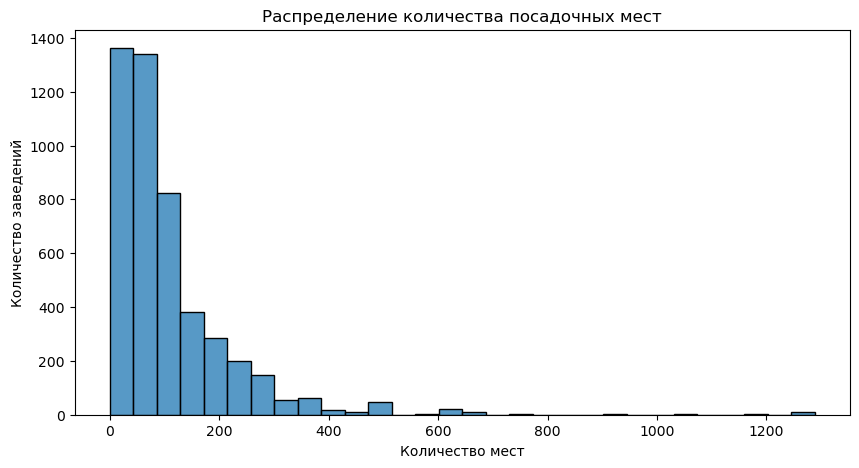

In [90]:
plt.figure(figsize=(10, 5))
sns.histplot(df['seats'], bins=30)

plt.title('Распределение количества посадочных мест')
plt.xlabel('Количество мест')
plt.ylabel('Количество заведений')
plt.show()

In [91]:
median_seats = (
    df.groupby('category')['seats']
      .median()
      .sort_values(ascending=False)
)


In [92]:
median_seats

category
ресторан           86.0
бар,паб            82.0
кофейня            80.0
столовая           75.5
быстрое питание    65.0
кафе               60.0
пиццерия           55.0
булочная           50.0
Name: seats, dtype: float64

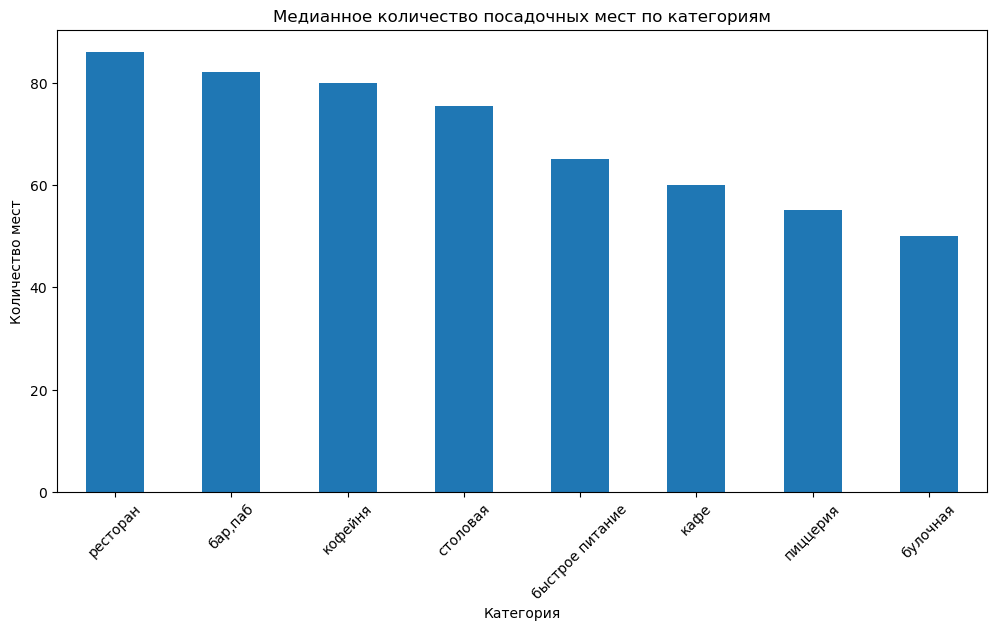

In [93]:
plt.figure(figsize=(12, 6))
median_seats.plot(kind='bar')
plt.xticks(rotation=45)
plt.title('Медианное количество посадочных мест по категориям')
plt.xlabel('Категория')
plt.ylabel('Количество мест')
plt.show()

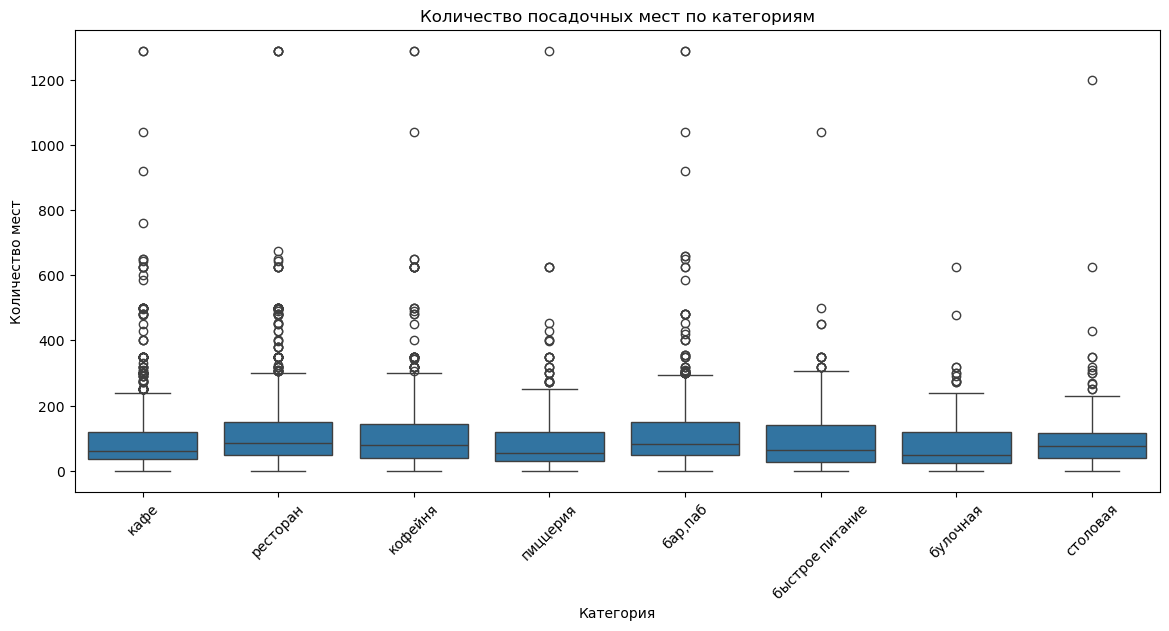

In [94]:
plt.figure(figsize=(14, 6))

sns.boxplot(
    data=df,
    x='category',
    y='seats'
)

plt.xticks(rotation=45)
plt.title('Количество посадочных мест по категориям')
plt.xlabel('Категория')
plt.ylabel('Количество мест')
plt.show()

Медианное число мест для большинства типов заведений находится в диапазоне 60-90. Существенных различий между категориями не наблюдается. Во всех категориях присутствуют выбросы, заведения с очень большой вместимостью.

---

### Задача 5

Исследуйте рейтинг заведений. Визуализируйте распределение средних рейтингов по категориям заведений. Сильно ли различаются усреднённые рейтинги для разных типов общепита?

In [95]:
avg_rating = (df.groupby('category')['rating'].mean()
          .sort_values(ascending=False))

In [96]:
avg_rating

category
бар,паб            4.387696
пиццерия           4.301264
ресторан           4.290402
кофейня            4.277282
булочная           4.268359
столовая           4.211429
кафе               4.123896
быстрое питание    4.050249
Name: rating, dtype: float64

Уже можно с уверенностью сказать что различия не сильные. 

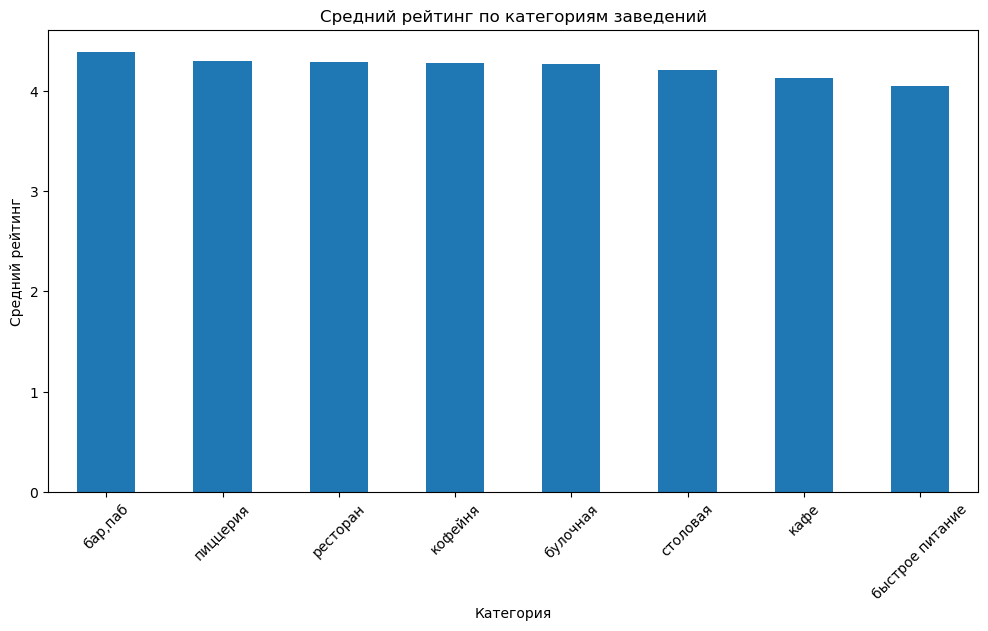

In [97]:
plt.figure(figsize=(12, 6))
avg_rating.plot(kind='bar')
plt.title('Средний рейтинг по категориям заведений')
plt.xlabel('Категория')
plt.ylabel('Средний рейтинг')
plt.xticks(rotation=45)
plt.show()

---

### Задача 6

Изучите, с какими данными показывают самую сильную корреляцию рейтинги заведений? Постройте и визуализируйте матрицу корреляции рейтинга заведения с разными данными: его категория, положение (административный район Москвы), статус сетевого заведения, количество мест, ценовая категория и признак, является ли заведения круглосуточным. Выберите самую сильную связь и проверьте её.

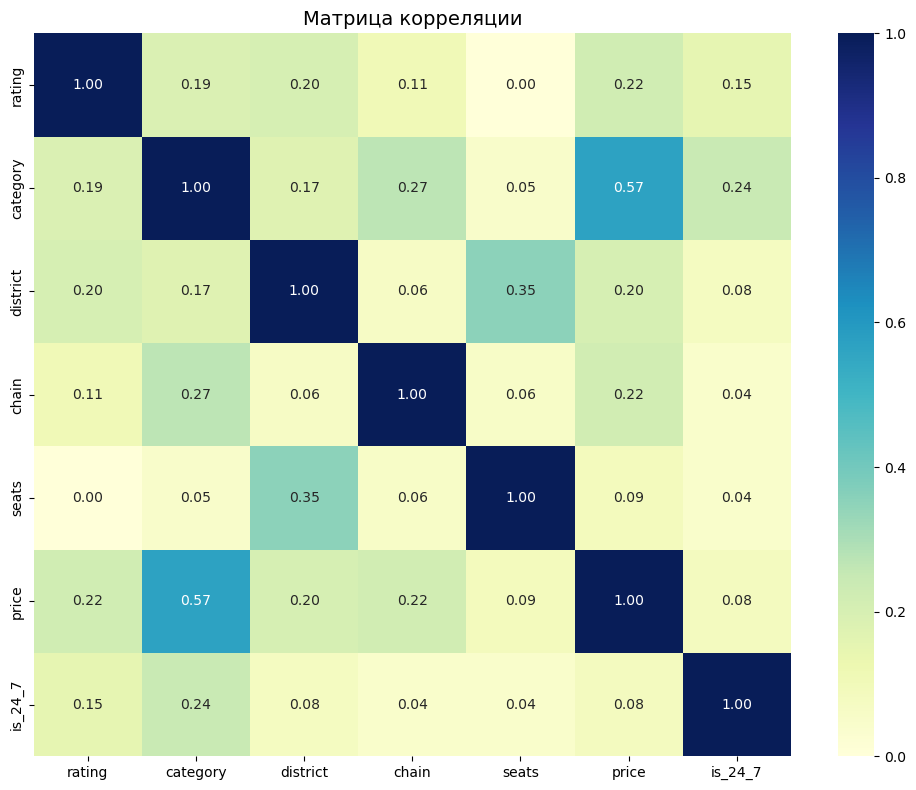

In [102]:
import phik
cols = ['rating', 'category', 'district', 'chain', 'seats', 'price', 'is_24_7']
df_phik = df[cols]
interval_cols = ['rating', 'seats']

phik_matrix = df_phik.phik_matrix(interval_cols=interval_cols)

plt.figure(figsize=(10, 8))
sns.heatmap(phik_matrix, annot=True, cmap='YlGnBu', fmt=".2f", vmin=0, vmax=1)
plt.title('Матрица корреляции', fontsize=14)
plt.tight_layout()
plt.show()

Самую сильную корреляцию с рейтингом заведения показывает признак price

---

### Задача 7

Сгруппируйте данные по названиям заведений и найдите топ-15 популярных сетей в Москве. Для них посчитайте значения среднего рейтинга. Под популярностью понимается количество заведений этой сети в регионе. К какой категории заведений они относятся? Результат сопроводите подходящими визуализациями.

In [104]:
top15 = (
    df[df['chain']]
    .groupby('name')
    .agg(
        establishments=('id', 'count'),
        avg_rating=('rating', 'mean')
    )
    .sort_values('establishments', ascending=False)
    .head(15)
)

top15

,establishments,avg_rating
name,,
шоколадница,120,4.177500
домино'с пицца,76,4.169737
додо пицца,74,4.286486
one price coffee,71,4.064789
яндекс лавка,69,3.872464
cofix,65,4.075385
prime,50,4.116000
хинкальная,44,4.322727
кофепорт,42,4.147619


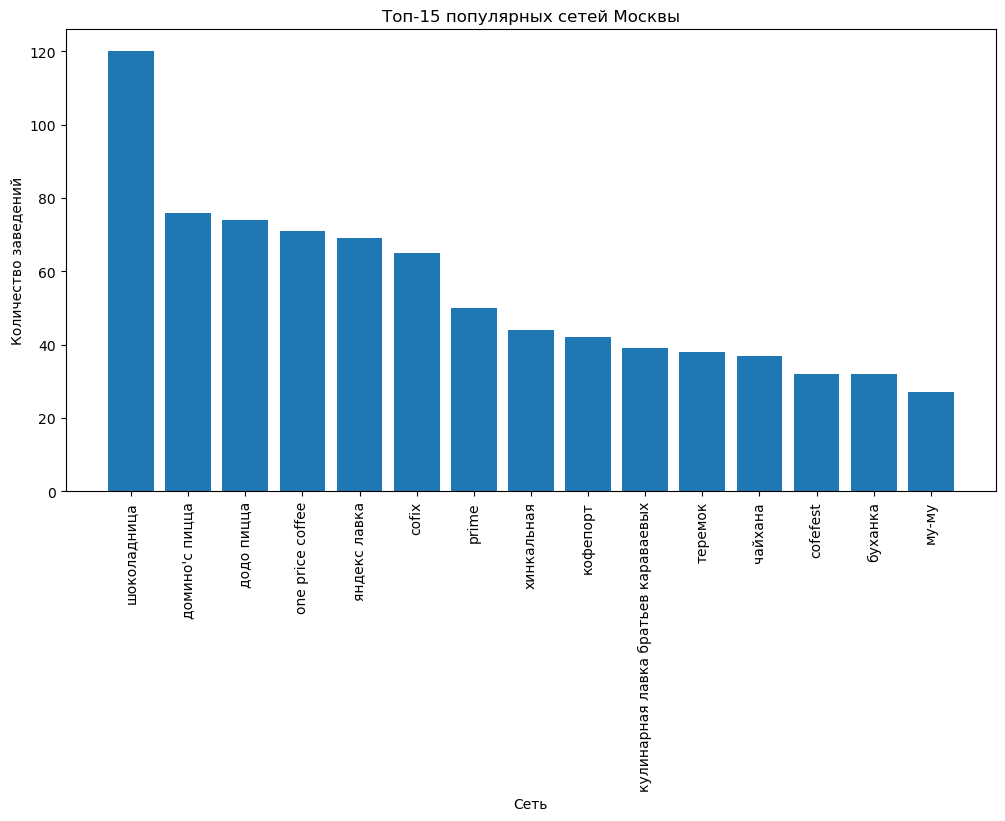

In [108]:
plt.figure(figsize=(12, 6))

plt.bar(
    top15.index,
    top15['establishments']
)
plt.xticks(rotation=90)
plt.title('Топ-15 популярных сетей Москвы')
plt.xlabel('Сеть')
plt.ylabel('Количество заведений')
plt.show()

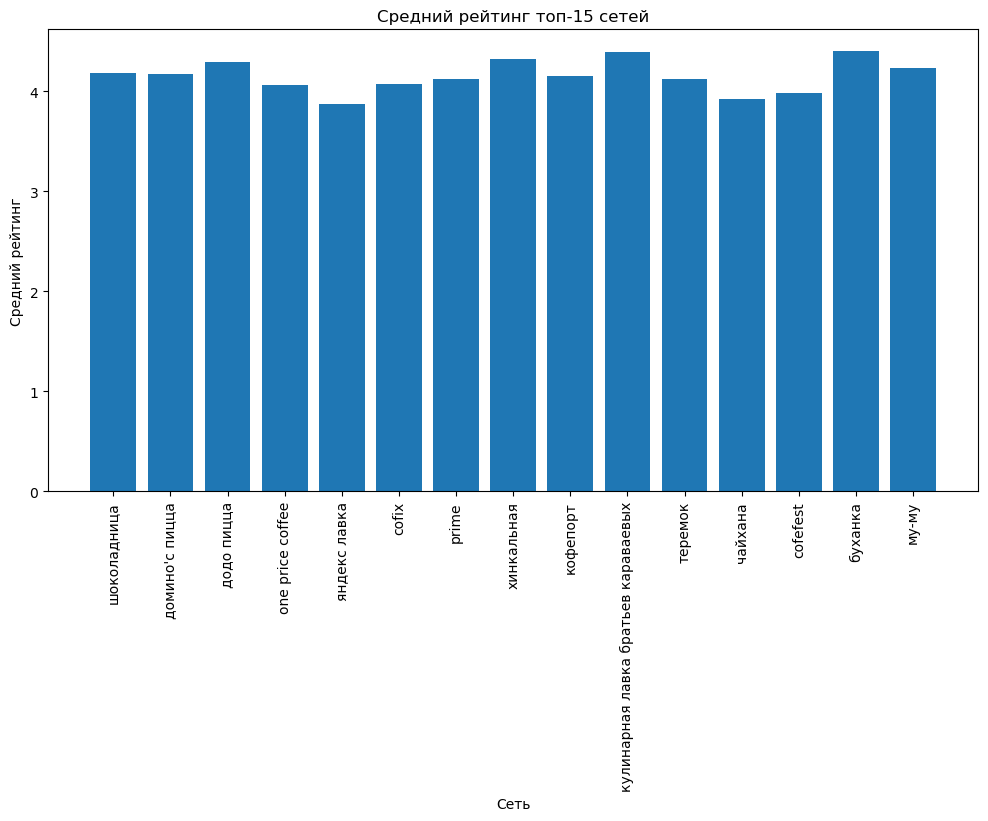

In [107]:
plt.figure(figsize=(12, 6))
plt.bar(
    top15.index,
    top15['avg_rating']
)
plt.xticks(rotation=90)
plt.title('Средний рейтинг топ-15 сетей')
plt.xlabel('Сеть')
plt.ylabel('Средний рейтинг')
plt.show()

Были определены 15 самых популярных сетевых заведений Москвы по количеству точек. Для каждой сети рассчитан средний рейтинг. Среди лидеров преобладают заведения категорий «кафе», «ресторан быстрого питания», «кофейня». Средний рейтинг популярных сетей находится на достаточно высоком уровне

---

### Задача 8

Изучите вариацию среднего чека заведения (столбец `middle_avg_bill`) в зависимости от района Москвы. Проанализируйте цены в Центральном административном округе и других. Как удалённость от центра влияет на цены в заведениях? Результат сопроводите подходящими визуализациями.


In [109]:
df['middle_avg_bill'].isna().sum() #Пропусков достаточно много их нужно бы убрать

np.int64(5254)

In [110]:
bill_df = df.dropna(subset=['middle_avg_bill'])

In [112]:
district_bill = (
    bill_df
    .groupby('district')['middle_avg_bill']
    .mean()
    .sort_values(ascending=False)
)

---


In [113]:
district_bill

district
Центральный административный округ         1191.057547
Западный административный округ            1053.225490
Северный административный округ             927.959627
Южный административный округ                834.398089
Северо-Западный административный округ      822.222930
Восточный административный округ            820.626923
Юго-Западный административный округ         792.561702
Северо-Восточный административный округ     716.611296
Юго-Восточный административный округ        654.097938
Name: middle_avg_bill, dtype: float64

In [115]:
district_bill.loc['Центральный административный округ']

np.float64(1191.0575471698114)

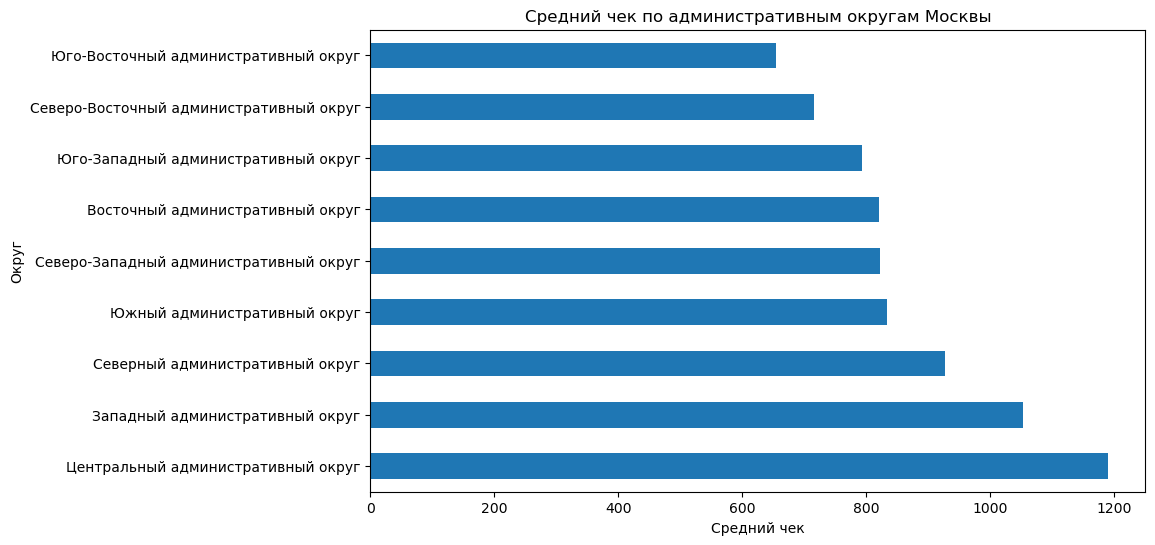

In [114]:
plt.figure(figsize=(10, 6))
district_bill.plot(kind='barh')
plt.title('Средний чек по административным округам Москвы')
plt.xlabel('Средний чек')
plt.ylabel('Округ')
plt.show()

Можно увидеть что в ЦАО в среднем средний чек выше

---

### Промежуточный вывод

Обобщите полученные результаты, выделив, по вашему мнению, самые важные.

В ходе исследования были изучены характеристики заведений общественного питания Москвы. В датасете представлены различные категории заведений: кафе, рестораны, бары, кофейни и т.д. Большая часть заведений не относится к сетям, однако сетевые организации занимают заметную долю рынка и представлены большим количеством точек по всему городу. Большинство заведений имеют от 40 до 140 посадочных мест 

Наиболее высокие значения среднего чека наблюдаются в Центральном административном округе

## 4. Итоговый вывод и рекомендации

По результатам проведённого исследовательского анализа данных сформулируйте итоговый вывод и рекомендации для заказчика. Старайтесь акцентировать внимание на ключевых моментах исследования.

При составлении вывода придерживайтесь такой структуры:

1. Общий обзор проделанной работы.
2. Ответы на исследовательские вопросы, или главные выводы.
3. Рекомендации на основе анализа данных.

На рынке общественного питания Москвы представлено большое разнообразие категорий заведений, среди которых наиболее распространены кафе, рестораны и кофейни.
Большинство заведений являются несетевыми, однако крупнейшие сети имеют значительное количество точек и занимают важную часть рынка.
Средний чек существенно зависит от расположения заведения. Самые высокие цены характерны для ЦАО, тогда как в удалённых районах цены обычно ниже.

При открытии нового заведения следует учитывать особенности округа и платёжеспособность аудитории района.
Для премиальных заведений наиболее перспективными могут быть центральные районы города, где средний чек выше.
Для массового сегмента и сетевых проектов стоит рассматривать округа за пределами центра, т.к на условия окупаемости может влиять стоимость арены и конкуренция